![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_1/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  SVD en reconocimiento facial

En este caso-taller vamos a aplicar SVD para hacer reconocimiento facial. Esta aplicación se conoce como caras propias, o eigenfaces en inglés, y si bien es una forma rudimentaria de reconocimiento facial sus resultados pueden ser muy interesantes. El problema de las caras propias fue estudiado por primera vez por Sirovich y Kirby en 1987, ampliado en 1990 y su aplicación al reconocimiento facial automatizado fue presentado por Turk and Pentland en 1991.

En este taller vamos a utilizar la base de datos conocida como Caras Etiquetadas en la Naturaleza, o Labeled Faces in the Wild (LFW). Esta base es provista por la Universidad de Massachusetts Amherst para que la comunidad académica la utilice para la evaluación de modelos predictivos.

La base contiene más de 13.000 imágenes de rostros recopilados de la web y cada cara ha sido etiquetada con el nombre de la persona representada. Un subconjunto de 1.680 de las personas fotografiadas tienen dos o más fotos distintas en el conjunto de datos.



#### Referencias

- G. B. Huang,  M. Ramesh, T. Berg, and E. Learned-Miller. Labeled Faces in the Wild: A Database for Studying Face Recognition in Unconstrained Environments. University of Massachusetts, Amherst, Technical Report 07-49, October, 2007.

- M. Kirby and L. Sirovich. Application of the Karhunen-Loève procedure for the characterization of human faces. IEEE Transactions on Pattern Analysis and Machine Intelligence (PAMI), 12(1):103–108, 1990.

- L. Sirovich and M. Kirby. A low-dimensional procedure for the characterization of human faces. Journal of the Optical Society of America A, 4(3):519–524, 1987

- M. Turk and A. Pentland. Eigenfaces for recognition. Journal of Cognitive Neuroscience, 3(1):71–86, 1991.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

Los datos pueden ser descargados directamente utilizando la librería `scikit-learn`, para ello cargue la base utilizando la función `fetch_lfw_people`. Esta función verificará si los datos están disponibles. De no estarlo, `scikit-learn` los descargará automáticamente desde el sitio web de la Universidad de Massachusetts. Descargue las imágenes para individuos que tengan al menos 25 imágenes y guárdelos en una carpeta llamada `data` usando esta función.

In [1]:
# Utilice este espacio para escribir el código.

#### Función para instalar las librerías usadas en la primera parte del Taller 1 (en caso de que no las tenga instaladas)
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada')    

### Lista con el nombre de las librerías usadas en el ejercicio
librerias_taller = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn']

### Loop-for para las librerías
for i in librerias_taller:
    install_load(i)

#### Librerías usadas en la primera parte del Taller 1
import os                                 ##  Interacción con directorios                 
import numpy as np                        ##  Computación científica en Python
import pandas as pd                       ##  Manejo y manipulación de datos en Python
import matplotlib.pyplot as plt           ##  Gráficos básicos en Python
import seaborn as sns                     ##  Gráficos estadísticos en Python

from sklearn.datasets import fetch_lfw_people ##  Función para cargar el dataset de caras LFW con la librería sklearn

### Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')    


# ================================================================================================================================================
# 1. Cargamos los datos
#================================================================================================================================================

### Definimos, con la librería os, una nueva ruta que nos permita guardar las imágenes en la carpeta 'data' del repositorio en GitHub
data_path =  os.path.join('..', 'data')

### Cargamos el dataset de las imágenes de caras LFW
lfw_people = fetch_lfw_people(min_faces_per_person=25, 
                              resize = 0.4, 
                              data_home = 'data_path')

print('La descarga de las imágenes ha sido exitosa')

La librería numpy ya está instalada
La librería pandas ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería sklearn ya está instalada
La descarga de las imágenes ha sido exitosa


(Utilice este espacio para describir su procedimiento)

- 1. Creamos la función install_load() para verificar si las librerías usadas están instaladas en el computador local, si no ocurre lo anterior las librerías son instaladas mediante -pip. Posteriormente, importamos las librerías que vamos a utilizar en el taller de PCA. En la parte derecha está una corta descripción de cada una de ellas.

- 2. Ruta de datos: para seguir el orden de directorios creados en el repositorio de Github, es necesario crear un objeto (data_path) que redefina la ruta que guarde las imágenes en la carpeta de data.

- 3. Carga de imágenes: con la función *fetch_lfw_people()*, del paquete sklearn, podemos extraer al menos 25 imágenes que sean guardadas en el objeto data_path (ruta de data en GitHub).  


### 2.  Análisis preliminar

Describa los contenidos de la base, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes.

In [2]:
# Utilice este espacio para escribir el código.

# ================================================================================================================================================
# 2. Cargamos los datos
#================================================================================================================================================

### a. Extraemos las dimensiones del dataset de imágenes
n_samples, h, w = lfw_people.images.shape

### b. Denominamos a X como la matriz de datos 
X = lfw_people.data

### c. Extraemos el número de columnas de la matriz de datos (X)
n_features = X.shape[1]

### d. Definimos la variable *y* como el array de etiquetas del dataset
y = lfw_people.target

### e. Creamos el array con los nombres de las personas del dataset
names_people = lfw_people.target_names

### f. Tomamos el número de filas del array de nombres de personas
n_classes = names_people.shape[0]


print("=== Resumen de la Base de Datos ===")
print(f"Total de imágenes (observaciones): {n_samples}")
print(f"Dimensión de cada foto: {h} pixeles de alto x {w} pixeles de ancho")
print(f"Total de pixeles por imagen (Columnas en X): {n_features}")
print(f"Cantidad de individuos distintos: {n_classes}")

=== Resumen de la Base de Datos ===
Total de imágenes (observaciones): 2588
Dimensión de cada foto: 50 pixeles de alto x 37 pixeles de ancho
Total de pixeles por imagen (Columnas en X): 1850
Cantidad de individuos distintos: 42


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

- **Extracción de las dimensiones:**

- **Matriz de datos:**

- **Número de columnas de la matriz X:**

- **Array con las etiquetas del dataset X:** cada imagen tiene un número que funciona como ID, estos códigos los tomamos a partir de la función *lfw_people.target* y la guardamos en el objeto *y*.

- **Array de los nombres:** las imágenes también tienen los nombres reales de la persona representada, guardamos todos estos strings en un arreglo de NumPy con la línea *lfw_people.target_names* y guardamos el array en el objeto *names_people*

- **Número de filas:** extraemos del objeto *names_people*, el número de filas que corresponde al número de nombres de las imágenes. 


A continuación responda las siguientes preguntas:

- ¿Cuál es la distribución de imágenes por individuos?

C:\Users\fevid\AppData\Local\Temp\ipykernel_14300\3542393746.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = images_count.index, y = images_count.values, palette='viridis')


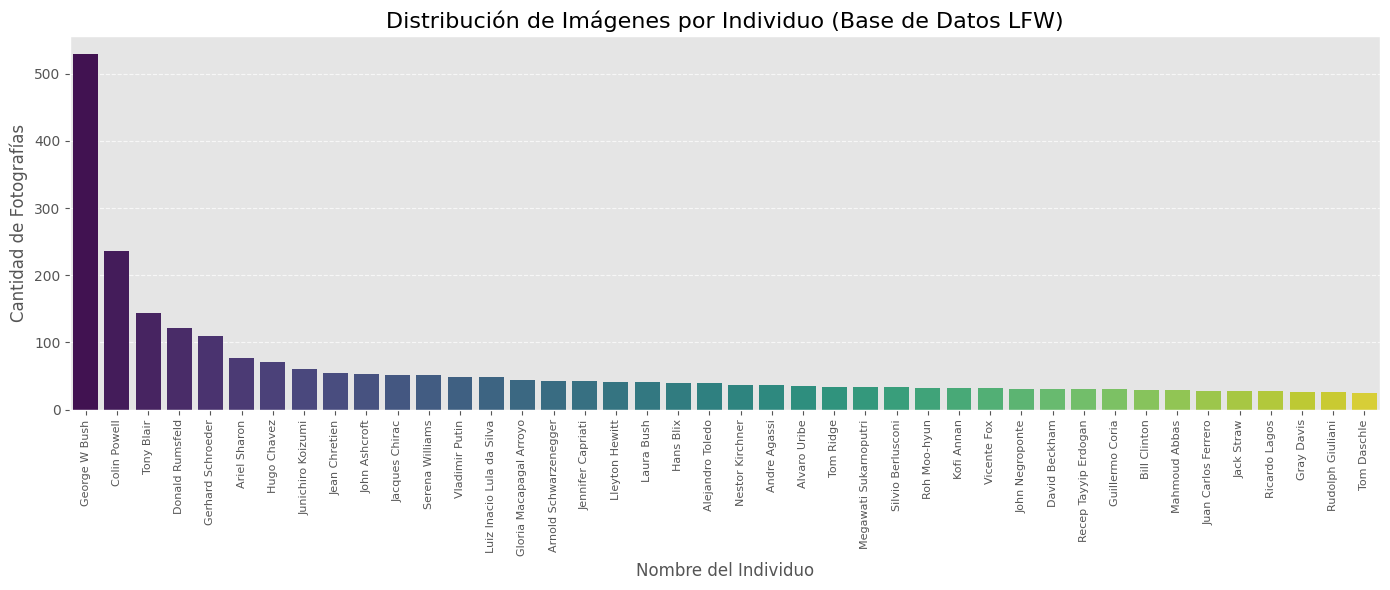

In [27]:
# Utilice este espacio para escribir el código.
# ========================================================================================================================================================================
# 3. DISTRIBUCIÓN DE IMÁGENES POR INDIVIDUOS
# ========================================================================================================================================================================

### a. Contamos cuantas veces aparece cada nombre de las personas en el dataset
name_tags = names_people[y]

### b. Volvemos este objeto (name_tags) una serie de Pandas
images_count = pd.Series(name_tags).value_counts()


### c.
plt.figure(figsize=(14, 6))
plt.xticks(rotation=90, fontsize=8)
sns.barplot(x = images_count.index, y = images_count.values, palette='viridis')
plt.title('Distribución de Imágenes por Individuo (Base de Datos LFW)', fontsize=16)
plt.ylabel('Cantidad de Fotografías', fontsize=12)
plt.xlabel('Nombre del Individuo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### d.  

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

- ¿Cuántas imágenes pertenecen a Serena Williams? Grafíquelas

In [4]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

### 3.  Reconociendo rostros: las eigenfaces

Las eigenfaces son un conjunto de eigenvectors utilizados en el campo de la visión por computadora, principalmente en el reconocimiento de rostros. Son el resultado de reducir la dimensión de un gran conjunto de imágenes faciales, manteniendo la información que es más relevante para diferenciar las caras.

En este apartado buscaremos encontrar el espacio de menor dimensión manteniendo la información que es más relevante para diferenciar las caras. Lo haremos en etapas:


#### 3.1. Rostro promedio.

Encuentre primero el "rostro promedio" y grafíquelo.  Para encontrar este rostro, necesita calcular el valor promedio de los pixeles. (*Tip: Si X es la matriz donde las filas representan las imágenes  y en las columnas el tono de gris de los píxeles, debería calcular el promedio para cada una de las columnas*).


In [5]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.2. Reste el rostro promedio.

A cada una de las imágenes, reste el rostro promedio, es decir, reste la media a cada columna. Grafique las imágenes de Serena Williams luego de quitarle el rostro promedio.

In [6]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.3. Descomposición en Valores Singulares

Aplique la Descomposición en Valores Singulares a estas nuevas imágenes y retenga solo $K=1000$ valores singulares? ¿Qué proporción de la varianza representan esto valores singulares?

In [7]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.4. Representando los rostros en las bases

Las eigenfaces nos dice que cada rostro puede ser representado a partir de la aproximación a la matriz original por la matriz de dimensión reducida determinada en el punto anterior más el rostro promedio. Muestre que esto es posible para las imágenes de Serena Williams. Compare las imágenes reconstruidas con las originales.

In [8]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

### 4. Uniendo Aprendizaje No Supervisado y Supervisado

Dado que cada rostro puede ser representado por las eigenfaces, y la relación que existe entre componentes principales y la SVD, esto sugiere que los componentes principales aquí determinados pueden servir de insumo para un algoritmo de clasificación de aprendizaje supervisado. En este sección del taller haremos esto.

Para ello construiremos un modelo de clasificación logístico para predecir si la imagen pertenece a `George W Bush`  (el individuo con más imágenes en la base)  o no.

#### 4.1. Identificando a `George W Bush`

Cree una variable binaria que tome el valor 1 si la imagen pertenece a `George W Bush` y 0 en caso contrario.

In [9]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.2. Bases de Entrenamiento y Prueba.

Divida la base utilizada anteriormente en dos: 80% de la base de imágenes asígnelas a la base de entrenamiento y el 20% restante a la de prueba, utilice un `random_state=10101`.

In [10]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.3. Descomposición en Valores Singulares

Para la base de entrenamiento y de prueba, realice la descomposición en valores singulares (Recuerde recentrar las matrices para que tenga media 0).

In [11]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.4. Estimación de modelo de aprendizaje supervisado


Utilizando $k=1000$ valores singulares, construya los 1000 primeros componentes principales y úselos como predictores en su modelo logístico. Utilice como métrica de performance el porcentaje de imágenes de `George W Bush` clasificadas correctamente.

Para estimar su modelo logístico Utilice el `solver='sag`,`random_state=10101` y `max_iter=1000`. Como se muestra a continuación:



In [12]:
from sklearn.linear_model import LogisticRegression

Modelo_Logistico = LogisticRegression(solver='sag',random_state=10101,max_iter=1000)

# Utilice este espacio para escribir el código restante.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.5. Mejorando el Ajuste

Trate ahora el número de valores singulares como un hiper-parámetro a encontrar. Emplee validación cruzada con 5 o 10 folds (dependiendo de su poder computacional) para encontrar el número óptimo de valores singulares. Con este modelo, evalúe el porcentaje de imágenes de `George W Bush` clasificadas correctamente en su muestra de prueba. Compare y discuta esta forma de elegir el número de variables con aquella utilizada en  4.4. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [13]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).